In [4]:
from keras.layers import Input, Lambda, Dense, Flatten
from keras.models import Model
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os


path_to_images = '/content/drive/MyDrive/60 ẢNH'

# Kiểm tra xem thư mục có tồn tại không và liệt kê file
if os.path.exists(path_to_images):
    files = os.listdir(path_to_images)
    print(f"Tìm thấy thư mục! Số lượng file bên trong: {len(files)}")
    print("Một số file mẫu:", files[:5])
else:
    print("Không tìm thấy thư mục. Vui lòng kiểm tra lại tên thư mục trên Drive của bạn.")

Tìm thấy thư mục! Số lượng file bên trong: 31
Một số file mẫu: ['NGUYEN HOANG BAO', 'TRAN NGOC THAO ANH', 'TRAN MINH HOANG', 'LE THAI BAO', 'TRINH THUY HANG']


In [ ]:
import os

base_path = '/content/drive/MyDrive/60 ẢNH'

count = 0
if os.path.exists(base_path):
    dirs = os.listdir(base_path)
    for d in dirs:
        sub_folder_path = os.path.join(base_path, d)
        if os.path.isdir(sub_folder_path):
            files = os.listdir(sub_folder_path)
            print(d + ' folder has ' + str(len(files)) + ' images')
            count = count + len(files)

    print('-------------------------------------')
    print(str(count) + ' images in total')
else:
    print("Không tìm thấy thư mục gốc. Bạn đã mount Drive và chạy đúng tên chưa?")

NGUYEN HOANG BAO folder has 60 images
TRAN NGOC THAO ANH folder has 60 images
TRAN MINH HOANG folder has 61 images
LE THAI BAO folder has 60 images
TRINH THUY HANG folder has 60 images
NGUYEN BAO HAN folder has 60 images
PHAM LY BAO LAM folder has 60 images
TRAN THE DANG KHOA folder has 60 images
NGUYEN NGOC KHANH UYEN folder has 60 images
MAI HO QUOC TUY folder has 60 images
TRAN GIA HAN folder has 60 images
LE HUYNH DUC HUY folder has 60 images
LE THI NHU QUYNH folder has 60 images
NGUYEN TRONG MINH folder has 60 images
PHAM MAI PHUONG folder has 58 images
HOANG BAO TRAN folder has 82 images
LE MINH TRIET folder has 60 images
DANG NGUYEN PHUONG NGHI folder has 60 images
NGUYEN KHAC LUU VU folder has 86 images
LE TRONG DAI folder has 70 images
NGUYEN HUU TOAN folder has 72 images
HA PHUONG THAO folder has 60 images
PHAM DUC THANH CONG folder has 60 images
THAI TUAN PHAT folder has 60 images
LE TRAN QUY ANH folder has 63 images
BUI DANG KHOI folder has 60 images
NGUYEN THI THANH HA fol

In [5]:
from keras.applications.vgg16 import VGG16
from glob import glob
from keras.layers import Flatten, Dense

IMAGE_SIZE = [224, 224]

vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)


for layer in vgg.layers:
  layer.trainable = False


base_path = '/content/drive/MyDrive/60 ẢNH'
folders = glob(f'{base_path}/*')


x = Flatten()(vgg.output)
prediction = Dense(len(folders), activation='softmax')(x)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
from tensorflow.keras.models import Model

# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

# view the structure of the model
model.summary()

# tell the model what cost and optimization method to use
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 31)             │       777,759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,492,447 (59.10 MB)

 Trainable params: 777,759 (2.97 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAINING_DATA_DIR = '/content/drive/MyDrive/60 ẢNH'
VALIDATION_SPLIT = 0.2

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True,
                                   validation_split=VALIDATION_SPLIT)

test_datagen = ImageDataGenerator(rescale = 1./255,
                                  validation_split=VALIDATION_SPLIT)

training_set = train_datagen.flow_from_directory(TRAINING_DATA_DIR,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical',
                                                 subset='training',
                                                 color_mode='rgb')

test_set = test_datagen.flow_from_directory(TRAINING_DATA_DIR,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical',
                                            subset='validation',
                                            color_mode='rgb')

Found 1544 images belonging to 31 classes.
Found 381 images belonging to 31 classes.


Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1251s 26s/step - accuracy: 0.9955 - loss: 0.0380 - val_accuracy: 0.8005 - val_loss: 0.7338
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1262s 26s/step - accuracy: 1.0000 - loss: 0.0202 - val_accuracy: 0.8346 - val_loss: 0.6907
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1238s 25s/step - accuracy: 0.9994 - loss: 0.0192 - val_accuracy: 0.8136 - val_loss: 0.7335
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1264s 26s/step - accuracy: 0.9981 - loss: 0.0173 - val_accuracy: 0.8241 - val_loss: 0.7438
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1275s 26s/step - accuracy: 0.9987 - loss: 0.0149 - val_accuracy: 0.8189 - val_loss: 0.7481


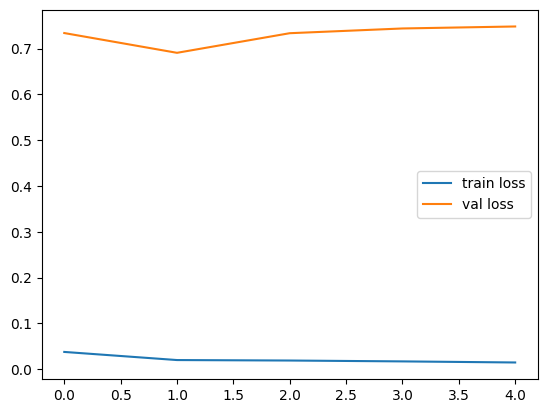

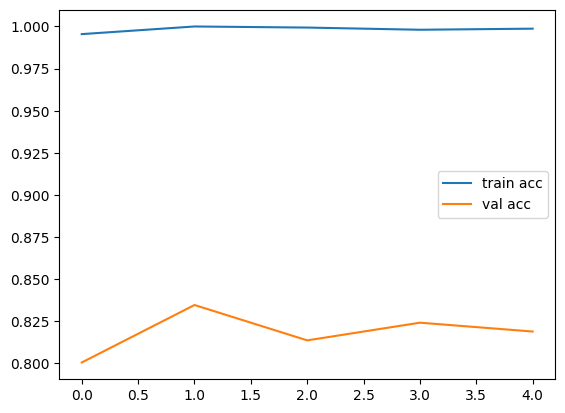

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

# fit the model
r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=5,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)
# loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# accuracies
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [ ]:
training_set.class_indices

{'BUI DANG KHOI': 0,
 'DANG NGUYEN PHUONG NGHI': 1,
 'HA PHUONG THAO': 2,
 'HOANG BAO TRAN': 3,
 'HOANG BUI TRA MY': 4,
 'LE HUYNH DUC HUY': 5,
 'LE MINH TRIET': 6,
 'LE THAI BAO': 7,
 'LE THI NHU QUYNH': 8,
 'LE TRAN QUY ANH': 9,
 'LE TRONG DAI': 10,
 'MAI HO QUOC TUY': 11,
 'NGUYEN BAO HAN': 12,
 'NGUYEN DONG HAI': 13,
 'NGUYEN HOANG BAO': 14,
 'NGUYEN HUU TOAN': 15,
 'NGUYEN KHAC LUU VU': 16,
 'NGUYEN NGOC KHANH UYEN': 17,
 'NGUYEN NGOC KIM TUYET': 18,
 'NGUYEN THI THANH HA': 19,
 'NGUYEN TRONG MINH': 20,
 'NHAN MANH TUAN': 21,
 'PHAM DUC THANH CONG': 22,
 'PHAM LY BAO LAM': 23,
 'PHAM MAI PHUONG': 24,
 'THAI TUAN PHAT': 25,
 'TRAN GIA HAN': 26,
 'TRAN MINH HOANG': 27,
 'TRAN NGOC THAO ANH': 28,
 'TRAN THE DANG KHOA': 29,
 'TRINH THUY HANG': 30}

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np # Ensure numpy is imported for expand_dims

test_image = image.load_img('/content/IMG_3382.PNG', target_size = (IMAGE_SIZE[0], IMAGE_SIZE[1])) # Use img_width, img_height
test_image = image.img_to_array(test_image)
test_image = test_image/255 # Normalization should happen after converting to array
test_image = np.expand_dims(test_image, axis = 0)
result = model.predict(test_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step


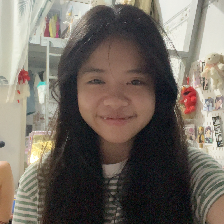

Predicted: TRAN GIA HAN


In [ ]:
from PIL import Image

labels = dict((v,k) for k,v in training_set.class_indices.items())

pred = np.argmax(result)

display_image = Image.fromarray((test_image[0] * 255).astype(np.uint8))
display(display_image)
print("Predicted:", labels[pred])

In [7]:
from google.colab import drive
drive.mount('/content/drive')

model_path_h5 = '/content/drive/MyDrive/face_recognition.h5'

model.save(model_path_h5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
